In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
google_file   = r"F:\SEM-7\Time Series Analysis\Project\Data\google_data.csv"
yfinance_file = r"F:\SEM-7\Time Series Analysis\Project\Data\tsm_yfinance_data.csv"
google   = pd.read_csv(google_file)
yfinance = pd.read_csv(yfinance_file)

print("GOOGLE FINANCE")
print(google.head())
print("\nShape:", google.shape)

print("\nYAHOO FINANCE")
print(yfinance.head())
print("\nShape:", yfinance.shape)

GOOGLE FINANCE
                  Date  Open  High   Low  Close   Volume
0      8/10/1997 16:00  5.49  5.51  5.22   5.49  2579124
1      9/10/1997 16:00  5.59  6.49  5.58   6.26  2167736
2     10/10/1997 16:00  6.94  6.97  6.29   6.55  2267033
3  13/10/1997 16:00:00  6.56  6.56  6.37   6.40   647081
4  14/10/1997 16:00:00  6.35  6.36  5.97   6.14   541983

Shape: (7273, 6)

YAHOO FINANCE
         Date      Open      High       Low     Close  Adj Close    Volume
0   10/9/1997  5.646040  6.562691  5.646040  6.323565   3.122905  10201979
1  10/10/1997  7.014374  7.040944  6.363419  6.615830   3.267240  10669148
2  10/13/1997  6.629115  6.629115  6.443128  6.469698   3.195073   3044363
3  10/14/1997  6.416558  6.429843  6.031299  6.204002   3.063857   2549907
4  10/15/1997  5.818742  6.044584  5.805458  6.031299   2.978568   3167153

Shape: (7274, 7)


In [18]:
print("GOOGLE FINANCE")
print("Columns:")
print(google.columns.tolist())
print("\nData types:")
print(google.dtypes)
print("\nMissing values:")
print(google.isnull().sum())

print("\n\nYAHOO FINANCE")
print("Columns:")
print(yfinance.columns.tolist())
print("\nData types:")
print(yfinance.dtypes)
print("\nMissing values:")
print(yfinance.isnull().sum())

GOOGLE FINANCE
Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Data types:
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


YAHOO FINANCE
Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [4]:
# Convert dates
google["Date"] = pd.to_datetime(google["Date"],dayfirst=True,format="mixed").dt.normalize()
yfinance["Date"] = pd.to_datetime(yfinance["Date"],dayfirst=False,format="mixed").dt.normalize()

# Sort by date
google = google.sort_values("Date").reset_index(drop=True)
yfinance = yfinance.sort_values("Date").reset_index(drop=True)

print("GOOGLE FINANCE")
print(google.head())
print(google.dtypes)

print("\nYAHOO FINANCE")
print(yfinance.head())
print(yfinance.dtypes)

GOOGLE FINANCE
        Date  Open  High   Low  Close   Volume
0 1997-10-08  5.49  5.51  5.22   5.49  2579124
1 1997-10-09  5.59  6.49  5.58   6.26  2167736
2 1997-10-10  6.94  6.97  6.29   6.55  2267033
3 1997-10-13  6.56  6.56  6.37   6.40   647081
4 1997-10-14  6.35  6.36  5.97   6.14   541983
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

YAHOO FINANCE
        Date      Open      High       Low     Close  Adj Close    Volume
0 1997-10-09  5.646040  6.562691  5.646040  6.323565   3.122905  10201979
1 1997-10-10  7.014374  7.040944  6.363419  6.615830   3.267240  10669148
2 1997-10-13  6.629115  6.629115  6.443128  6.469698   3.195073   3044363
3 1997-10-14  6.416558  6.429843  6.031299  6.204002   3.063857   2549907
4 1997-10-15  5.818742  6.044584  5.805458  6.031299   2.978568   3167153
Date         datetime64[ns]
Open                float64
High                floa

In [5]:
google_dates = set(google["Date"])
yahoo_dates = set(yfinance["Date"])

common_dates = google_dates.intersection(yahoo_dates)
google_only = google_dates - yahoo_dates
yahoo_only = yahoo_dates - google_dates

print("GOOGLE FINANCE")
print("First date :", google["Date"].min())
print("Last date  :", google["Date"].max())
print("Rows       :", len(google))

print("\nYAHOO FINANCE")
print("First date :", yfinance["Date"].min())
print("Last date  :", yfinance["Date"].max())
print("Rows       :", len(yfinance))

print("\nDATE COMPARISON")
print("Common dates :", len(common_dates))
print("Google only  :", len(google_only))
print("Yahoo only   :", len(yahoo_only))

GOOGLE FINANCE
First date : 1997-10-08 00:00:00
Last date  : 2026-09-10 00:00:00
Rows       : 7273

YAHOO FINANCE
First date : 1997-10-09 00:00:00
Last date  : 2026-09-10 00:00:00
Rows       : 7274

DATE COMPARISON
Common dates : 7271
Google only  : 2
Yahoo only   : 3


In [6]:
# Merge both datasets on common dates
comparison = pd.merge(google,yfinance,on="Date",how="inner",suffixes=("_Google", "_Yahoo"))
# Sort by date
comparison = comparison.sort_values("Date").reset_index(drop=True)

print("Comparison dataset shape:", comparison.shape)
print("\nColumns:")
print(comparison.columns.tolist())
print("\nFirst 5 rows:")
print(comparison.head())

Comparison dataset shape: (7271, 12)

Columns:
['Date', 'Open_Google', 'High_Google', 'Low_Google', 'Close_Google', 'Volume_Google', 'Open_Yahoo', 'High_Yahoo', 'Low_Yahoo', 'Close_Yahoo', 'Adj Close', 'Volume_Yahoo']

First 5 rows:
        Date  Open_Google  High_Google  Low_Google  Close_Google  \
0 1997-10-09         5.59         6.49        5.58          6.26   
1 1997-10-10         6.94         6.97        6.29          6.55   
2 1997-10-13         6.56         6.56        6.37          6.40   
3 1997-10-14         6.35         6.36        5.97          6.14   
4 1997-10-15         5.76         5.98        5.74          5.97   

   Volume_Google  Open_Yahoo  High_Yahoo  Low_Yahoo  Close_Yahoo  Adj Close  \
0        2167736    5.646040    6.562691   5.646040     6.323565   3.122905   
1        2267033    7.014374    7.040944   6.363419     6.615830   3.267240   
2         647081    6.629115    6.629115   6.443128     6.469698   3.195073   
3         541983    6.416558    6.429843  

In [ ]:
# Define 15-year period
end_date   = yfinance["Date"].max()
start_date = end_date - pd.DateOffset(years=15)

# Filter Yahoo Finance data
tsm = yfinance[(yfinance["Date"] >= start_date) & (yfinance["Date"] <= end_date)].copy()
# Sort and reset index
tsm = tsm.sort_values("Date").reset_index(drop=True)

print("TSMC 15-YEAR DATASET")
print("Start date :", tsm["Date"].min())
print("End date   :", tsm["Date"].max())
print("Rows       :", len(tsm))

print("\nColumns:")
print(tsm.columns.tolist())
print("\nFirst 5 rows:")
print(tsm.head())
print("\nLast 5 rows:")
print(tsm.tail())

TSMC 15-YEAR DATASET
Start date : 2011-09-12 00:00:00
End date   : 2026-09-10 00:00:00
Rows       : 3771

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 rows:
        Date   Open   High    Low  Close  Adj Close    Volume
0 2011-09-12  11.76  11.99  11.70  11.94   8.143514  12798200
1 2011-09-13  11.87  11.98  11.78  11.96   8.157158  11612100
2 2011-09-14  11.83  11.93  11.61  11.82   8.061672  18850400
3 2011-09-15  12.00  12.20  12.00  12.11   8.259462  15916200
4 2011-09-16  12.35  12.51  12.26  12.41   8.464075  15643200

Last 5 rows:
           Date        Open        High         Low       Close   Adj Close  \
3766 2026-09-03  413.290008  417.299988  407.820007  417.010010  417.010010   
3767 2026-09-04  421.880005  429.820007  419.420013  428.910004  428.910004   
3768 2026-09-08  438.019989  444.290008  433.720001  439.000000  439.000000   
3769 2026-09-09  434.459992  439.399994  431.869995  435.359985  435.359985   
3770 2026-09-10  426.4400

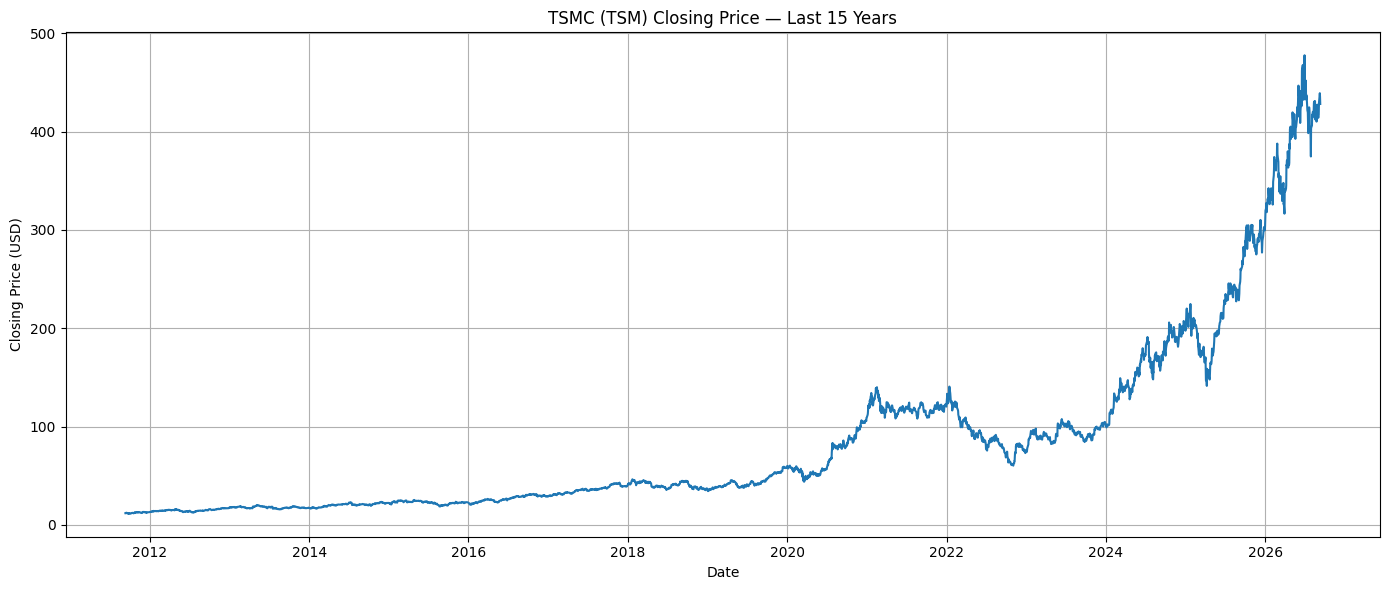

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(tsm["Date"], tsm["Close"])
plt.title("TSMC (TSM) Closing Price — Last 15 Years")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# FEATURE SET 1: PRICE & RETURN FEATURES

tsm["Log_Close"] = np.log(tsm["Close"])
tsm["Return_1D"] = tsm["Close"].pct_change()
tsm["Log_Return_1D"] = np.log(tsm["Close"]).diff()
tsm["High_Low_Range"] = ((tsm["High"]-tsm["Low"])/tsm["Close"])
tsm["Open_Close_Change"] = ((tsm["Close"]-tsm["Open"])/tsm["Open"])

print("Feature Set 1 created:")
print(["Log_Close","Return_1D","Log_Return_1D","High_Low_Range","Open_Close_Change"])

display(tsm[["Date","Open","High","Low","Close","Log_Close","Return_1D","Log_Return_1D","High_Low_Range","Open_Close_Change"]].head(10))

Feature Set 1 created:
['Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change']


,Date,Open,High,Low,Close,Log_Close,Return_1D,Log_Return_1D,High_Low_Range,Open_Close_Change
0,2011-09-12,11.76,11.99,11.70,11.94,2.479894,NaN,NaN,0.024288,0.015306
1,2011-09-13,11.87,11.98,11.78,11.96,2.481568,0.001675,0.001674,0.016722,0.007582
2,2011-09-14,11.83,11.93,11.61,11.82,2.469793,-0.011706,-0.011775,0.027073,-0.000845
3,2011-09-15,12.00,12.20,12.00,12.11,2.494032,0.024535,0.024239,0.016515,0.009167
4,2011-09-16,12.35,12.51,12.26,12.41,2.518503,0.024773,0.024471,0.020145,0.004858
5,2011-09-19,12.18,12.29,12.01,12.22,2.503074,-0.015310,-0.015429,0.022913,0.003284
6,2011-09-20,12.24,12.29,12.11,12.12,2.494857,-0.008183,-0.008217,0.014852,-0.009804
7,2011-09-21,12.22,12.31,11.91,11.92,2.478218,-0.016502,-0.016639,0.033557,-0.024550
8,2011-09-22,11.52,11.64,11.39,11.52,2.444085,-0.033557,-0.034133,0.021701,0.000000
9,2011-09-23,11.34,11.71,11.29,11.71,2.460443,0.016493,0.016358,0.035867,0.032628


In [ ]:
# FEATURE SET 2: LAG FEATURES

# Lagged closing prices
for lag in [1, 2, 3, 5, 10, 20]:
    tsm[f"Close_Lag_{lag}"] = tsm["Close"].shift(lag)

# Lagged daily returns
for lag in [1, 2, 3, 5, 10, 20]:
    tsm[f"Return_Lag_{lag}"] = tsm["Return_1D"].shift(lag)

# Display created features
lag_features = ["Close_Lag_1","Close_Lag_2",
                "Close_Lag_3","Close_Lag_5",
                "Close_Lag_10","Close_Lag_20",
                "Return_Lag_1","Return_Lag_2",
                "Return_Lag_3","Return_Lag_5",
                "Return_Lag_10","Return_Lag_20"]

print("Feature Set 2 created:")
print(lag_features)

display(tsm[["Date", "Close", "Return_1D"] + lag_features].head(25))

Feature Set 2 created:
['Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20']


,Date,Close,Return_1D,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Close_Lag_20,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20
0,2011-09-12,11.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-09-13,11.96,0.001675,11.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-09-14,11.82,-0.011706,11.96,11.94,NaN,NaN,NaN,NaN,0.001675,NaN,NaN,NaN,NaN,NaN
3,2011-09-15,12.11,0.024535,11.82,11.96,11.94,NaN,NaN,NaN,-0.011706,0.001675,NaN,NaN,NaN,NaN
4,2011-09-16,12.41,0.024773,12.11,11.82,11.96,NaN,NaN,NaN,0.024535,-0.011706,0.001675,NaN,NaN,NaN
5,2011-09-19,12.22,-0.015310,12.41,12.11,11.82,11.94,NaN,NaN,0.024773,0.024535,-0.011706,NaN,NaN,NaN
6,2011-09-20,12.12,-0.008183,12.22,12.41,12.11,11.96,NaN,NaN,-0.015310,0.024773,0.024535,0.001675,NaN,NaN
7,2011-09-21,11.92,-0.016502,12.12,12.22,12.41,11.82,NaN,NaN,-0.008183,-0.015310,0.024773,-0.011706,NaN,NaN
8,2011-09-22,11.52,-0.033557,11.92,12.12,12.22,12.11,NaN,NaN,-0.016502,-0.008183,-0.015310,0.024535,NaN,NaN
9,2011-09-23,11.71,0.016493,11.52,11.92,12.12,12.41,NaN,NaN,-0.033557,-0.016502,-0.008183,0.024773,NaN,NaN


In [ ]:
# FEATURE SET 3: MOVING AVERAGE / TREND

for window in [5, 10, 20, 50]:
    tsm[f"SMA_{window}"] = (tsm["Close"].rolling(window=window).mean())

sma_features = ["SMA_5","SMA_10","SMA_20","SMA_50"]
print("Feature Set 3 created:")
print(sma_features)

display(tsm[["Date", "Close"] + sma_features].tail(10))

Feature Set 3 created:
['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50']


,Date,Close,SMA_5,SMA_10,SMA_20,SMA_50
3761,2026-08-27,427.299988,418.294000,419.029001,418.511501,423.7250
3762,2026-08-28,417.519989,418.007996,418.145999,419.175000,423.4324
3763,2026-08-31,415.320007,419.047998,416.581000,419.635501,422.4964
3764,2026-09-01,414.000000,418.365997,416.639999,419.477000,421.4230
3765,2026-09-02,415.500000,417.927997,416.981000,419.552000,421.0052
3766,2026-09-03,417.010010,415.870001,417.082001,419.492500,420.5288
3767,2026-09-04,428.910004,418.148004,418.078000,419.936000,420.4072
3768,2026-09-08,439.000000,422.884003,420.966000,420.962500,420.5402
3769,2026-09-09,435.359985,427.156000,422.760999,421.627499,420.1454
3770,2026-09-10,428.029999,429.662000,423.794998,421.571500,419.1546


In [ ]:
# FEATURE SET 4: VOLATILITY

for window in [5, 10, 20]:
    tsm[f"Volatility_{window}"] = (tsm["Log_Return_1D"].rolling(window=window).std())

volatility_features = ["Volatility_5","Volatility_10","Volatility_20"]
print("Feature Set 4 created:")
print(volatility_features)

display(tsm[["Date", "Close", "Log_Return_1D"] + volatility_features].tail(10))

Feature Set 4 created:
['Volatility_5', 'Volatility_10', 'Volatility_20']


,Date,Close,Log_Return_1D,Volatility_5,Volatility_10,Volatility_20
3761,2026-08-27,427.299988,0.022747,0.017236,0.019339,0.015401
3762,2026-08-28,417.519989,-0.023154,0.021306,0.020468,0.016467
3763,2026-08-31,415.320007,-0.005283,0.018443,0.019970,0.016521
3764,2026-09-01,414.000000,-0.003183,0.016421,0.014927,0.015383
3765,2026-09-02,415.500000,0.003617,0.016576,0.014913,0.015310
3766,2026-09-03,417.010010,0.003628,0.010972,0.014651,0.015157
3767,2026-09-04,428.910004,0.028137,0.013333,0.017059,0.016409
3768,2026-09-08,439.000000,0.023252,0.013728,0.015979,0.017091
3769,2026-09-09,435.359985,-0.008326,0.015180,0.016134,0.017187
3770,2026-09-10,428.029999,-0.016980,0.019536,0.017474,0.017277


In [ ]:
# FEATURE SET 5: MOMENTUM

for window in [5, 10, 20]:
    tsm[f"Momentum_{window}D"] = (tsm["Close"].pct_change(window))

momentum_features = ["Momentum_5D","Momentum_10D","Momentum_20D"]

print("Feature Set 5 created:")
print(momentum_features)
display(tsm[["Date", "Close"] + momentum_features].tail(10))

Feature Set 5 created:
['Momentum_5D', 'Momentum_10D', 'Momentum_20D']


,Date,Close,Momentum_5D,Momentum_10D,Momentum_20D
3761,2026-08-27,427.299988,0.027163,-0.007410,0.059483
3762,2026-08-28,417.519989,-0.003413,-0.020711,0.032826
3763,2026-08-31,415.320007,0.012679,-0.036313,0.022679
3764,2026-09-01,414.000000,-0.008169,0.001427,-0.007599
3765,2026-09-02,415.500000,-0.005243,0.008275,0.003623
3766,2026-09-03,417.010010,-0.024081,0.002428,-0.002846
3767,2026-09-04,428.910004,0.027280,0.023774,0.021117
3768,2026-09-08,439.000000,0.057016,0.070418,0.049060
3769,2026-09-09,435.359985,0.051594,0.043003,0.031512
3770,2026-09-10,428.029999,0.030156,0.024755,-0.002610


In [ ]:
# FEATURE SET 6: CALENDAR FEATURES

tsm["Day_of_Week"] = tsm["Date"].dt.dayofweek
tsm["Month"]       = tsm["Date"].dt.month
tsm["Quarter"]     = tsm["Date"].dt.quarter
tsm["Year"]        = tsm["Date"].dt.year

calendar_features = ["Day_of_Week","Month","Quarter","Year"]
print("Feature Set 6 created:")
print(calendar_features)
display(tsm[["Date"] + calendar_features].head(10))

Feature Set 6 created:
['Day_of_Week', 'Month', 'Quarter', 'Year']


,Date,Day_of_Week,Month,Quarter,Year
0,2011-09-12,0,9,3,2011
1,2011-09-13,1,9,3,2011
2,2011-09-14,2,9,3,2011
3,2011-09-15,3,9,3,2011
4,2011-09-16,4,9,3,2011
5,2011-09-19,0,9,3,2011
6,2011-09-20,1,9,3,2011
7,2011-09-21,2,9,3,2011
8,2011-09-22,3,9,3,2011
9,2011-09-23,4,9,3,2011


In [ ]:
master_file = r"F:\SEM-7\Time Series Analysis\Project\Data\TSMC_Master_Features_15Y.csv"
tsm.to_csv(master_file, index=False)

print("Master dataset saved successfully!")
print("File:", master_file)
print("Shape:", tsm.shape)
print("Features:", len(tsm.columns))

Master dataset saved successfully!
File: F:\SEM-7\Time Series Analysis\Project\Data\TSMC_Master_Features_15Y.csv
Shape: (3771, 38)
Features: 38
